# Quiz 4

<font size='4'>

BIOS-584<br>
Nov 21, 2025

* Write down your name in a Markdown section.

Sam Colgan

In [39]:
import numpy as np
import pandas as pd
import os
from datetime import datetime

## Preliminary

<font size='4'>
    
* There are six files stored under `Your own GitHub repository/data/Quiz4`.
* Import those six files using relevant functions in `Pandas`.

In [2]:
# Set directory and import text files
txt_dir = '{}/data/Quiz4'.format(os.getcwd())
data_1_df = pd.read_csv('{}/data_1.txt'.format(txt_dir), sep=',')
data_2_df = pd.read_csv('{}/data_2.txt'.format(txt_dir), sep=',')
data_3_df = pd.read_csv('{}/data_3.txt'.format(txt_dir), sep=',')
data_4_df = pd.read_csv('{}/data_4.txt'.format(txt_dir), sep=',')
data_5_df = pd.read_csv('{}/data_5.txt'.format(txt_dir), sep=',')
data_6_df = pd.read_csv('{}/data_6.txt'.format(txt_dir), sep=',')

## Import Data

<font size='4'>

* Three lists named `study_id_ls`, `measure_date_ls`, and `duration_ls` have been initialized.
* Write a for loop to extract and append the values of `study_id`, `measure_date`, and `duration` to `study_id_ls`, `measure_date_ls`, and `duration_ls`, respectively.

In [13]:
study_id_ls = []
measure_date_ls = []
duration_ls = []
all_df = pd.concat([data_1_df, data_2_df, data_3_df, data_4_df, data_5_df, data_6_df])

for df_iter in range(all_df.shape[0]):
    study_id_ls.append(all_df.iloc[df_iter, 0])
    measure_date_ls.append(all_df.iloc[df_iter, 1])
    duration_ls.append(all_df.iloc[df_iter, 2])

<font size='4'>

* Create a new Pandas Dataframe combining three lists and name it `input_df`.

In [23]:
input_dict = {'study_id': study_id_ls,
               'measure_date': measure_date_ls,
               'duration': duration_ls}
input_df = pd.DataFrame(input_dict)
print(input_df)

   study_id measure_date  duration
0         1   2025-01-01       100
1         1   2025-03-01       300
2         1   2025-02-01       200
3         1   2025-11-01        25
4         1   2025-11-01        20
5         1   2025-11-03        30


<font size='4'>

* Visualize `input_df`

<Axes: title={'center': 'Duration over time'}, xlabel='measure_date', ylabel='duration_ls'>

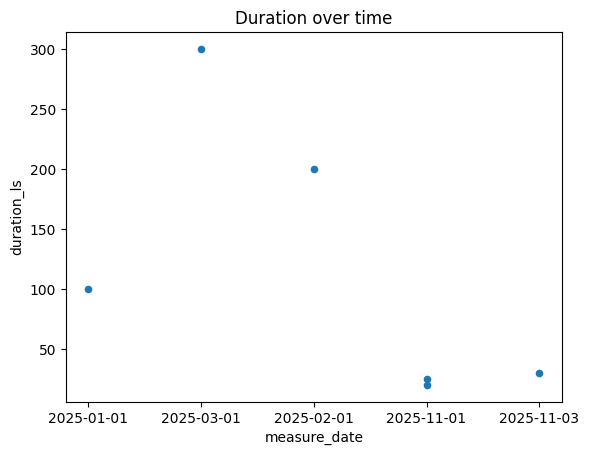

In [21]:
input_df.plot(x = 'measure_date', y = 'duration', kind = 'scatter', title = 'Duration over time')

## Data Manipulation

<font size='4'>

* Reorder the dataframe by `measure_date` (earliest to latest) and then by `duration` (shortest to longest).

In [25]:
input_df.sort_values(['measure_date', 'duration'], inplace = True)
print(input_df)

   study_id measure_date  duration
0         1   2025-01-01       100
2         1   2025-02-01       200
1         1   2025-03-01       300
4         1   2025-11-01        20
3         1   2025-11-01        25
5         1   2025-11-03        30


<font size='4'>

* Create a new column called `relative_time` by calculating the time difference in days between each of the measure date and the earliest one.

In [44]:
input_df['measure_date'] = pd.to_datetime(input_df['measure_date'])
input_df['relative_time'] = input_df['measure_date'] - input_df.loc[0, 'measure_date']
print(input_df)

   study_id measure_date  duration relative_time
0         1   2025-01-01       100        0 days
2         1   2025-02-01       200       31 days
1         1   2025-03-01       300       59 days
4         1   2025-11-01        20      304 days
3         1   2025-11-01        25      304 days
5         1   2025-11-03        30      306 days


<font size='4'>

* Reset the index column and remove the old index.

In [46]:
input_df.reset_index(drop = True, inplace = True)
print(input_df)

   study_id measure_date  duration relative_time
0         1   2025-01-01       100        0 days
1         1   2025-02-01       200       31 days
2         1   2025-03-01       300       59 days
3         1   2025-11-01        20      304 days
4         1   2025-11-01        25      304 days
5         1   2025-11-03        30      306 days


## Final Data Visualization
<font size='4'>
    
* Display the final `input_df`.